# IIO Scope Backend Walkthrough (vdpp_scope driver rewrite)

Live-tested calling pattern for `IIODigitizerBackend`'s `ScopeBackend` half,
rewritten from scratch against the board's rewritten `vdpp-scope.c` driver.
**Nothing from the previous `ewt-scope-iio`-based backend carries over** —
different device name, different attribute names, plain-integer trigger mode
instead of strings, a text-based (not binary) viewer attribute, and a
standard IIO dmaengine buffer instead of the old custom cyclic frame-ring.

**Scope only.** Covers both the viewer path (`read_frame()`, low-resolution,
polled) and the DMA capture path (`capture_to_file()`, full-resolution, to
file). DMA previously failed live with `OSError: [Errno 110] host
unreachable` (a `xilinx-vdma` kernel DMA-engine issue, not fixable from this
notebook) — that has since been fixed board-side and DMA capture now
succeeds. It comes with two caveats worth knowing before trusting captured
data blindly: the first two frames of every fresh capture buffer are stale
garbage, and `enable`/`dma_enable` can transiently read `True` for a brief
window after a capture ends before self-clearing. Both are covered where
they come up below and in the notes section at the end.

**MCA note:** `d.mca` is unusable — this driver rewrite only covers the
scope core so far, no pulse-processor equivalent has been ported yet. Every
`MultiChannelAnalyzer` call raises `NotImplementedError`.

**Hardware note:** the board's IP has moved before (seen at `.128` and
`.135`) — and the two addresses may not even be running the same driver
revision at a given time (confirmed once: `.128` on the new `vdpp_scope`
driver while `.135` was still on the old `ewt-scope0/1` driver). Run
`iio_info -u "ip:<host>:30431"` and look for a `vdpp_scope` device (not
`ewt-scope0`) before assuming this notebook applies to whatever's at the
address you're pointing at.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

from nlab.hardware.digitizer import Digitizer

HOST = "192.168.10.128"
PORT = 30431
CHANNEL = 0  # 0 -> first "vdpp_scope" device found, 1 -> second
             # (both instances share the identical device name on this
             # driver -- there's no per-instance label like the old
             # ewt-scope0/ewt-scope1 naming, so selection is purely by
             # discovery order)

d = Digitizer.from_iio(CHANNEL, f"ip:{HOST}:{PORT}")
scope = d.scope
print("connected:", scope is not None)

connected: True


## Device info

`ip_version` is a real, confirmed register this time (unlike the previous
driver, which had nothing literally named `ip_version` on the scope device) —
the probe function itself refuses to bind unless this reads exactly `121`
(`SCOPE_IP_VERSION_EXPECTED` in `vdpp-scope.c`), so seeing that value here is
a genuine identity check, not just informational.

In [2]:
print("ip_version      :", scope.get_ip_version(), "(expect 121)")
print("mem_frame_size  :", scope.get_mem_frame_size(), "entries (viewer memory depth)")

ip_version      : 121 (expect 121)
mem_frame_size  : 2048 entries (viewer memory depth)


## Configure acquisition parameters

`frame_samples` and `pretrigger_samples` must be multiples of 4 (the core
divides sample counts by 4 internally; other values are rejected outright,
not rounded) — enforced both by the driver and by `Scope`'s own parameter
specs. The device boots with `frame_samples=0`, which is below the driver's
own minimum (4), so this has to be set before anything else works.

`trigger_mode` is now a plain integer register (0=level-above, 1=level-below,
2=edge-falling, 3=edge-rising, 4=periodic) that already matches
`TriggerMode`'s int values 1:1 — no string translation involved anymore.

In [3]:
from nlab.hardware.digitizer import TriggerMode

scope.set_frame_samples(168)
scope.set_pretrigger_samples(16)
scope.set_trigger_level(-1000)
scope.set_trigger_mode(TriggerMode.ANY_BELOW)

print("frame_samples      :", scope.get_frame_samples())
print("pretrigger_samples :", scope.get_pretrigger_samples())
print("trigger_level      :", scope.get_trigger_level())
print("trigger_mode       :", scope.get_trigger_mode())

frame_samples      : 168
pretrigger_samples : 16
trigger_level      : -1000
trigger_mode       : 1


## DC offset (AFE DAC)

`vdpp_afe_dac` was added to the device tree after this backend was first
written -- `get_dac_value()`/`set_dac_value()` used to be no-op stubs since
there was nothing real to talk to. One `vdpp_afe_dac` device is shared by
both scope channels (unlike `vdpp_scope`, which uses one device instance per
channel): output channel `voltage0` maps to scope channel 0, `voltage1` to
channel 1, confirmed live.

The channel exposes two different attributes -- easy to mix up:
- `raw`: the underlying DAC output code, full range, not what this controls.
- `baseline`: the actual DC-offset value, range 0-1023 (confirmed live via
  `baseline_available`). This is what `get_dac_value()`/`set_dac_value()`
  read and write.

`Scope`'s own `DAC_VALUE` spec used to allow up to 1024; the driver rejects
1024 with `OSError: [Errno 34] Result too large` (`ERANGE`), so the spec was
corrected to 0-1023 to match.

In [4]:
orig_dac = scope.get_dac_value()
print("dac_value (current) :", orig_dac)

scope.set_dac_value(700)
print("dac_value (set 700) :", scope.get_dac_value())

scope.set_dac_value(orig_dac)
print("dac_value (restored):", scope.get_dac_value())

dac_value (current) : 512
dac_value (set 700) : 700
dac_value (restored): 512


## Arm once, acquire repeatedly (viewer path)

Unlike the previous driver, arming and reading are cleanly separated here:

- `scope.start()` (`set_enable(True)`) toggles a real, persistent `ENABLE`
  register bit -- no software flag involved, and it stays set until
  `scope.stop()`.
- `scope.acquire_frame()` (`read_frame()`) is self-contained and cheap to
  call repeatedly: per `vdpp-scope.c`'s `viewer_data_show()`, each read
  raises the pulse-viewer semaphore, sleeps out the worst-case frame time
  (~20-25ms) so it can't catch a half-written pulse, copies memory, and
  drops the semaphore -- all inside that one call. No separate arm-per-read
  step is needed.

Confirmed live: three consecutive reads below returned genuinely different
data each time (real, changing signal), not a frozen/stale snapshot.

read 0: shape=(42,) dtype=int16 min=0 max=0
read 1: shape=(42,) dtype=int16 min=0 max=0
read 2: shape=(42,) dtype=int16 min=0 max=0


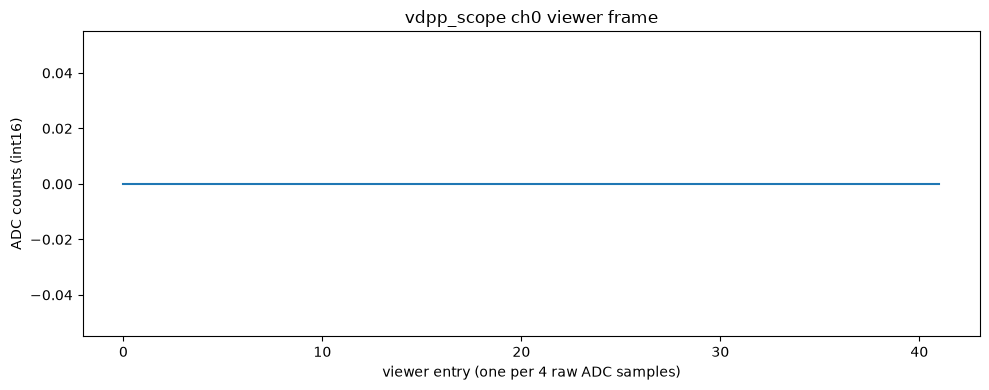

In [5]:
scope.start()

frame = None
for i in range(3):
    frame = scope.acquire_frame()
    print(f"read {i}: shape={frame.shape} dtype={frame.dtype} min={frame.min()} max={frame.max()}")

scope.stop()

plt.figure(figsize=(10, 4))
plt.plot(frame)
plt.xlabel("viewer entry (one per 4 raw ADC samples)")
plt.ylabel("ADC counts (int16)")
plt.title(f"vdpp_scope ch{CHANNEL} viewer frame")
plt.tight_layout()
plt.show()

## Full-resolution capture to file (`capture_to_file()`)

`IIODigitizerBackend.capture_to_file(path, duration_s=None, max_frames=None)`
mirrors the reference stub's method of the same name: it repeatedly refills
the DMA capture buffer and writes each frame's raw bytes straight to file
(64-bit timestamp header included, unmodified), stopping after
`max_frames`/`duration_s` and always closing the buffer afterward, success or
failure. It's an extension method, not part of `ScopeBackend`'s abstract
interface, so it's called on the backend directly (`d._backend`), not
through `scope`.

DMA previously failed here every time with `OSError: [Errno 110] host
unreachable` (~2.5s in) — a `xilinx-vdma` kernel DMA-engine issue, confirmed
via `dmesg` (`Cannot stop channel`, `DMAIntErr`, `SGIntErr`), not something
fixable client-side. That's since been fixed board-side; capture now
completes normally.

**Buffer sizing changed with a board/driver update.** It used to require a
buffer of `2 * frame_samples` samples (the dmaengine buffer core splitting
the request into two double-buffered blocks, with one `refill()` delivering
both at once — worked around client-side by splitting each refill's bytes
into individual frames). Confirmed via `dmesg` after a board update
(`buffer length is 1024, must be 512 for a 512 sample frame`) that
`scope_buffer_preenable()`'s required length is now exactly `frame_samples`
— one `refill()` now delivers exactly one frame, no client-side splitting
needed anymore.

A meaningful capture needs a trigger that actually fires at a known rate —
the level trigger configured in the viewer section above won't do for this.
Switching to periodic mode needs `frame_period_cycles`, which has no
getter/setter on `ScopeBackend`'s interface; `get_frame_period_cycles()`/
`set_frame_period_cycles()` were added to `IIODigitizerBackend` as extension
methods (same pattern as `capture_to_file()` itself) for exactly this. The
settings below (512 samples, 512 clocks period) reproduce the reference
example's own worked case: a 640-clock interval, ~195,312 frames/s and
200 MB/s requested against a link that sustains roughly 50 MB/s — so most
frames are expected to be dropped under backpressure, not lost to any bug.
`frame_period_cycles` is a plain register, no EBUSY guard on this driver
(unlike `frame_samples`), so it can be written any time.

In [6]:
from nlab.hardware.digitizer import TriggerMode

scope.set_frame_samples(512)
scope.set_pretrigger_samples(64)
d._backend.set_frame_period_cycles(512)
scope.set_trigger_mode(TriggerMode.TIMED)  # SCOPE_TRIG_PERIODIC on the driver side

interval_cycles = d._backend.get_frame_period_cycles() + scope.get_frame_samples() // 4
frame_rate_hz = 1e9 / (interval_cycles * 8)  # 8 ns per datapath clock

print("frame_samples       :", scope.get_frame_samples())
print("pretrigger_samples  :", scope.get_pretrigger_samples())
print("frame_period_cycles :", d._backend.get_frame_period_cycles())
print("trigger_mode        :", scope.get_trigger_mode())
print("interval            :", interval_cycles, "clocks =", interval_cycles * 8, "ns")
print(f"frame rate          : {frame_rate_hz:,.0f} per second")
print(f"data rate           : {frame_rate_hz * scope.get_frame_samples() * 2 / 1e6:.1f} MB/s")

frame_samples       : 512
pretrigger_samples  : 64
frame_period_cycles : 512
trigger_mode        : 4
interval            : 640 clocks = 5120 ns
frame rate          : 195,312 per second
data rate           : 200.0 MB/s


In [7]:
import os
import time

capture_path = "capture_test.bin"

t0 = time.monotonic()
try:
    n_frames = d._backend.capture_to_file(capture_path, duration_s=10.0)
    dt = time.monotonic() - t0
    print(f"capture_to_file(): {n_frames} frames written in {dt:.2f}s")
    print("file size:", os.path.getsize(capture_path), "bytes  (expected per frame:",
          scope.get_frame_samples() * 2, ")")
except Exception as e:
    dt = time.monotonic() - t0
    print(f"capture_to_file() FAILED after {dt:.2f}s: {type(e).__name__}: {e}")

# enable/dma_enable can transiently read True (or reject a write with
# -EBUSY) for a brief window right after the buffer closes -- confirmed
# live to settle within ~50ms, but not guaranteed, and closing the buffer
# doesn't always clear both bits at the same instant (one run showed
# enable=False, dma_enable=True right after). Retry briefly instead of
# treating a transient EBUSY here as a real failure.
def _retry_ebusy(fn, attempts=15, delay_s=0.02):
    for attempt in range(attempts):
        try:
            fn()
            return
        except OSError as e:
            if e.errno != 16 or attempt == attempts - 1:
                raise
            time.sleep(delay_s)

print("enable right after:", scope.get_enable(), " dma_enable right after:", d._backend.get_dma_enable())
_retry_ebusy(scope.stop)
_retry_ebusy(lambda: d._backend.set_dma_enable(False))
time.sleep(0.1)
print("enable settled     :", scope.get_enable(), " dma_enable settled     :", d._backend.get_dma_enable())

capture_to_file(): 9605 frames written in 11.08s
file size: 9835520 bytes  (expected per frame: 1024 )
enable right after: False  dma_enable right after: False
enable settled     : False  dma_enable settled     : False


## Parsing the capture file

Each frame is `frame_samples` int16 values, first 4 being a 64-bit trigger
timestamp (little-endian datapath clocks), the rest ADC payload shifted left
by `ADC_SHIFT=4`.

Two things confirmed live and worth handling explicitly rather than
discovering by surprise:

- **Frame 0 of a fresh capture is *occasionally* stale.** Used to be
  reliably the first two frames, every time -- traced to the old
  `2 * frame_samples` buffer sizing (see the markdown above). With that
  fixed, it's no longer a guaranteed, deterministic failure: two back to
  back captures with identical settings gave a clean frame 0 once and a
  stale one (failing the low-4-bits-clear check, timestamp not matching
  the fast-low/stable-high word pattern) the other time. Rather than
  blindly discarding frame 0 -- which would throw away good data half the
  time -- validate it the same way the rest of the analysis already does
  and only drop it if it actually fails.
- **Decode the timestamp from raw bytes, not via a numpy cast.** The
  reference stub's own `frame_timestamp()` does
  `frame[:4].astype(np.uint64)` on an `int16` array — numpy sign-extends
  any header word with its top bit set (i.e. most of them) before OR-ing,
  corrupting the reconstructed value. `int.from_bytes(header_bytes,
  "little")` on the raw bytes is correct; `IIODigitizerBackend.
  read_dma_frame()` already does this, but a raw file dump like this one
  has to redo it manually.

In [8]:
HEADER_SAMPLES = 4
ADC_SHIFT = 4

frame_samples = scope.get_frame_samples()
frame_bytes = frame_samples * 2

with open(capture_path, "rb") as f:
    raw = f.read()

n_captured = len(raw) // frame_bytes
frames = np.frombuffer(raw[: n_captured * frame_bytes], dtype="<i2").reshape(n_captured, frame_samples)
print(f"{n_captured} frames in file")

if n_captured == 0:
    raise RuntimeError(
        "0 frames in the capture file -- nothing to parse. Re-run the "
        "capture_to_file() cell above (this happens if it's run out of "
        "order, or if the capture genuinely captured nothing)."
    )

def frame_timestamp(frame_row: np.ndarray) -> int:
    return int.from_bytes(frame_row[:HEADER_SAMPLES].tobytes(), "little")

alignment_ok = np.all((frames[:, HEADER_SAMPLES:] & 0x000F) == 0, axis=1)
print(f"{alignment_ok.sum()} of {n_captured} frames pass the low-4-bits-clear check")

# Frame 0 is occasionally (not always) stale -- see markdown above. Validate
# instead of blindly discarding, so a good frame 0 isn't thrown away.
if not alignment_ok[0]:
    print("frame 0 failed alignment -- dropping it")
    valid = frames[1:]
    valid_idx = np.arange(1, n_captured)
else:
    print("frame 0 looks fine -- keeping it")
    valid = frames
    valid_idx = np.arange(n_captured)

timestamps = np.array([frame_timestamp(f) for f in valid])
deltas = np.diff(timestamps)
interval = d._backend.get_frame_period_cycles() + frame_samples // 4
# Every gap is some non-negative number of intervals, dropped frames or not --
# dropping frames only multiplies the interval, it can't change the remainder.
# A non-multiple here means a misdecoded/corrupted frame, not just a drop.
clean = np.count_nonzero(deltas % interval == 0)
print(f"interval = {interval} clocks; {clean} of {len(deltas)} consecutive gaps are a clean "
      f"multiple of it (anything else would mean a corrupted or misdecoded frame)")

9605 frames in file
9605 of 9605 frames pass the low-4-bits-clear check
frame 0 looks fine -- keeping it
interval = 640 clocks; 9604 of 9604 consecutive gaps are a clean multiple of it (anything else would mean a corrupted or misdecoded frame)


## Ten random frames from the capture

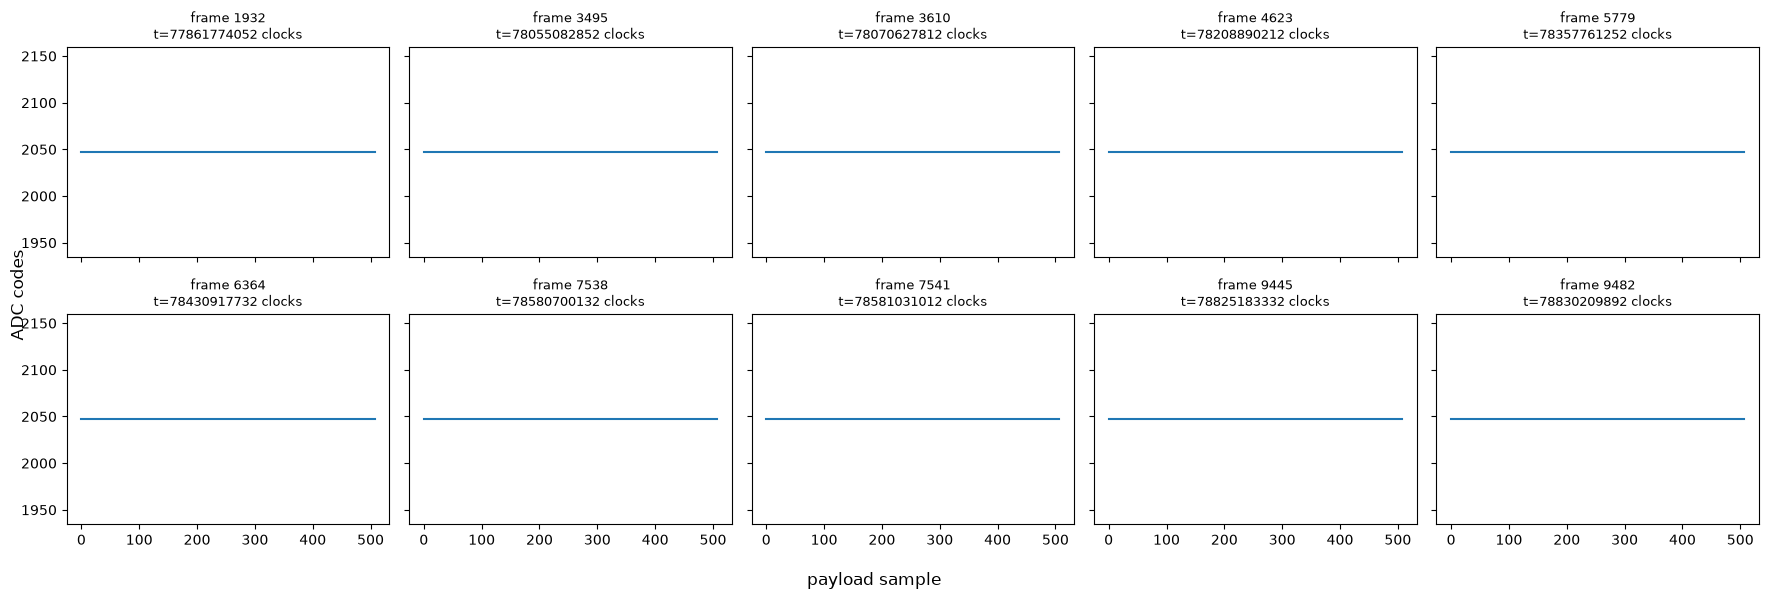

In [9]:
rng = np.random.default_rng()
n_pick = min(10, len(valid))
picked = np.sort(rng.choice(len(valid), size=n_pick, replace=False))

fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharex=True, sharey=True)
for ax, i in zip(axes.flat, picked):
    payload = valid[i, HEADER_SAMPLES:] >> ADC_SHIFT
    ts = frame_timestamp(valid[i])
    ax.plot(payload)
    ax.set_title(f"frame {valid_idx[i]}\nt={ts} clocks", fontsize=9)
for ax in axes.flat[n_pick:]:
    ax.axis("off")
fig.supxlabel("payload sample")
fig.supylabel("ADC codes")
plt.tight_layout()
plt.show()

In [10]:
d.close()

## Notes / gotchas worth knowing before extending this notebook

- **`get_enable`/`set_enable` and `get_dma_enable`/`set_dma_enable` are real
  register reads this time**, not software flags like the previous driver
  needed. Per `vdpp-scope.c`'s `enable_store()`/`dma_enable_store()`: both
  are rejected with `-EBUSY` while a DMA capture buffer is open (the buffer
  setup ops own these bits exclusively in that case) -- an expected mutual
  exclusion between viewer-only operation and buffer-owned capture, not a
  bug.
- **Every config attribute now transparently disarms/re-arms around its
  write, not just `frame_samples`.** Originally only `frame_samples` was
  guarded (`st->running || scope_is_running(st)`, confirmed from the
  driver source) while `trigger_level_raw`/`trigger_mode`/
  `pretrigger_samples`/`frame_period_cycles` had no such guard at all.
  That's since changed board-side: confirmed live via a GUI crash
  (adjusting the trigger-level spinbox mid-measurement raised a raw
  `OSError: [Errno 16]`) that all of these now reject writes with `-EBUSY`
  while armed too. `IIODigitizerBackend._write_config_attr()` is the
  shared helper every config setter goes through now, rather than
  special-casing `frame_samples` alone -- so callers don't need to stop
  first for any of them. Order matters: it closes the DMA buffer *before*
  touching `enable`, since `postenable()` sets `enable=1` whenever a buffer
  is open, so `enable`-first would hit the same `-EBUSY` guard it's trying
  to work around. If a *new* config attribute starts raising a raw
  `OSError` mid-measurement, route it through `_write_config_attr()` too
  rather than assuming it's exempt -- the driver's guard coverage has
  changed more than once already.
- **`viewer_samples` is a real driver bug, don't trust it for sizing.**
  Confirmed from the source: `viewer_data_show()` (the actual data path)
  computes its entry count as `frame_length / 4`, matching its own "one
  viewer entry is the average of 4 samples" comment -- but `viewer_samples_
  show()` returns `frame_length` **undivided**, despite carrying the
  identical comment. Confirmed live: `frame_samples=168` -> 42 real entries
  from `viewer_data` (168 // 4, correct) while `viewer_samples` itself
  reports 168. `IIODigitizerBackend.read_frame()` computes the expected
  count itself (`frame_samples // 4`) rather than trusting this attribute.
- **Large text attributes need the same 1024-byte workaround as before.**
  `pylibiio` 0.25's `DeviceAttr._read()` hardcodes a 1024-byte buffer;
  `viewer_data` is capped at `PAGE_SIZE` (4096 bytes) by the driver itself,
  which already exceeds that default. Read via the private `iio._d_read_
  attr` binding with an 8192-byte buffer instead (see `_read_large_attr` in
  `iio_backend.py`). Note this is the *device*-attribute low-level call, not
  the debug-attribute one the previous driver rewrite needed --
  `viewer_data` is a plain device attribute here.
- **The oversized read buffer comes back padded with trailing NUL bytes**
  beyond the real text content -- the byte count `_d_read_attr` reports
  doesn't line up with the string's real length over the network transport.
  `read_frame()` truncates at the first NUL byte (C-string convention)
  before parsing.
- **The AFE DAC now has a real driver (`vdpp_afe_dac`).** One device shared
  by both scope channels, selected by output channel (`voltage0`/`voltage1`)
  rather than by device instance like `vdpp_scope` -- confirmed live that
  channel index maps 1:1 to the scope channel. Two attributes exist per
  channel and are easy to confuse: `raw` (the underlying DAC output code,
  not used here) and `baseline` (the actual DC-offset control, 0-1023,
  which is what `get_dac_value()`/`set_dac_value()` read and write). The
  `ad5686r` device on the live tree is a separate, unrelated DAC -- not
  this one.
- **DMA capture (`read_dma_frame()` and `capture_to_file()`) now works.**
  Every attempt used to fail with `OSError: [Errno 110] host unreachable`
  after ~2.5s, traced to a `xilinx-vdma` kernel DMA-engine issue below the
  scope driver itself (confirmed via `dmesg`: `Cannot stop channel`,
  `DMAIntErr`, `SGIntErr`) -- that's been fixed board-side, and captures now
  complete and produce data with self-consistent timestamps (see the
  "Parsing the capture file" section). If `capture_to_file()` starts raising
  `host unreachable` again, that's this same class of issue regressing, not
  something to debug in this codebase first.
- **DMA buffer sizing changed with a board/driver update -- confirmed via
  `dmesg`, not guessed.** It used to require `2 * frame_samples` samples
  (the dmaengine buffer core splitting the request into two double-buffered
  blocks, one `refill()` delivering both at once, worked around
  client-side by splitting each refill's bytes into individual frames).
  After a board update, `dmesg` showed `scope_buffer_preenable()` rejecting
  that old sizing outright (`buffer length is 1024, must be 512 for a 512
  sample frame`) -- the required length is now exactly `frame_samples`, one
  `refill()` = one frame, and the client-side splitting logic was removed
  as dead weight. If `capture_to_file()`/`read_dma_frame()` start failing
  with a buffer-length `EINVAL` again, check `dmesg` for this exact message
  before assuming the client code regressed -- it tells you directly what
  length the driver wants.
- **Frame 0 of a fresh DMA buffer is occasionally, not reliably, stale.**
  Before the buffer-sizing fix above, this was 100% reproducible (always
  exactly the first two frames, every capture). With the fix in place, two
  back-to-back captures with identical settings gave a clean frame 0 once
  and a stale one (failing the low-4-bits-clear check, garbage-looking
  timestamp) the other time -- so the old "always discard the first N
  frames" rule no longer applies cleanly. Validate frame 0 (alignment
  check) and only drop it if it actually fails, rather than blindly
  discarding it every time (see the parsing section).
- **The reference stub's own `frame_timestamp()` has a sign-extension bug.**
  It does `frame[:4].astype(np.uint64)` on an `int16` array -- numpy
  sign-extends any header word with its top bit set before OR-ing the four
  words together, which is most of them, so the reconstructed 64-bit value
  is usually garbage. `IIODigitizerBackend.read_dma_frame()` already avoids
  this via `int.from_bytes(raw[:8], "little")` on the raw bytes; any code
  parsing a raw `capture_to_file()` dump by hand (like the notebook cells
  above) needs to do the same, not reuse the stub's helper as-is.
- **Cleanup after a DMA capture is not instantaneous, success or failure.**
  Both `read_dma_frame()` and `capture_to_file()` close the capture buffer
  in a `finally` (`cancel()` then drop the reference), and it does settle
  back to a clean `enable=0`/`dma_enable=0` -- but confirmed live that a
  read taken *immediately* afterward can still catch `enable=True`/
  `dma_enable=True` (reproduced after both a failed and a fully successful
  capture), with both attributes reading clean again within about 50ms.
  Don't treat one immediate post-capture read as proof of a stuck device --
  check again after a short pause, or just call `scope.stop()`/
  `set_dma_enable(False)` explicitly and not worry about the transient at
  all (what this notebook does above). The same brief window can also
  reject a *write* with `-EBUSY` (not just show a stale read) if it lands
  right after a `buffer.cancel()`.
- **`get_frame_period_cycles`/`set_frame_period_cycles` are extension
  methods**, not part of `ScopeBackend`'s interface -- same pattern as
  `capture_to_file()` -- since periodic triggering isn't something the
  previous driver's `ScopeBackend` surface ever needed to express. Call
  them on `d._backend`, not `scope`. The interval formula is
  `frame_period_cycles + frame_samples // 4` clocks, confirmed live against
  captured timestamp deltas.